# ETL & DATA CLEANING : Prédiction de la Gravité des Accidents Routiers

## Introduction

Ce notebook effectue un processus complet de **nettoyage et préparation des données (ETL)** à partir des bases de données BAAC (Bulletin d'Analyse d'Accidents de la circulation). Disponible sur le site suivant: https://www.data.gouv.fr/datasets/bases-de-donnees-annuelles-des-accidents-corporels-de-la-circulation-routiere-annees-de-2005-a-2024

**Objectif final** : Produire un dataset clean, encodé et prêt pour la modélisation ML.

**Sources de données** (2021-2024) :
- **Caractéristiques (caract)** : Contexte de l'accident (jour, heure, météo, etc.)
- **Lieux (lieux)** : Localisation géographique et type de route
- **Véhicules (vehicules)** : Infos sur le véhicule impliqué
- **Usagers (usagers)** : **Table centrale (de fait)** - chaque ligne = une personne impliquée

**Structure du pipeline** :   

* Fusion Relationnelle : Agrégation de 4 ans de données (2021-2024) et jointures horizontales centrées sur la table Usagers.

* Nettoyage de Structure : Suppression des colonnes vides à plus de 70 %, retrait des données de localisation trop fines (PR/PR1) et élimination des doublons.

* Prévention du Leakage : Suppression des variables connues uniquement après l'accident pour garantir l'intégrité prédictive du modèle.

* Feature Engineering : Création de variables à fort signal 

* Finalisation : Imputation des valeurs manquantes (médiane/mode) et encodage final (One-Hot Encoding) pour rendre le dataset exploitable par une IA.


# 1. Import des bibliothèques

In [6]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 2. Préparation et agrégation des données

In [7]:
# Configuration des répertoires
raw_path = "../data/raw/"
processed_path = "../data/processed/"
os.makedirs(processed_path, exist_ok=True)

## 2.1 Concaténation (empilement vertical des années)   
Les données sont fragmentées par année (2021-2024). Pour une analyse globale, il faut regrouper ces fichiers pour chaque thématique (Usagers, Véhicules, etc.).   
Stratégie : Nous créons une fonction qui parcourt les années, lit les fichiers correspondants et les "empile" verticalement. Cette séparation permet d'ajouter facilement de nouvelles années au projet sans modifier la logique de fusion.

In [8]:
years = [2021, 2022, 2023, 2024]


def stack_years(category):
    dfs = []
    for y in years:
        file = os.path.join(raw_path, f"{category}-{y}.csv")
        if os.path.exists(file):
            dfs.append(pd.read_csv(file, sep=";", encoding="utf-8", low_memory=False))
    return pd.concat(dfs, ignore_index=True)


# Centralisation
usagers_all = stack_years("usagers")
veh_all = stack_years("vehicules")
caract_all = stack_years("caract")
lieux_all = stack_years("lieux")

print(f"Historique Usagers : {len(usagers_all)} lignes.")

Historique Usagers : 506886 lignes.


## 2.2 Jointure relationnelle  
Les données BAAC sont morcelées en quatre fichiers annuels (Caractéristiques, Lieux, Véhicules, Usagers). Une fusion maladroite peut entraîner une perte de données ou une duplication artificielle des lignes.   
 *Stratégie* : La table Usagers est notre table de fait centrale car la variable cible grav. Nous effectuons une jointure "Left Join" pour conserver tous les usagers et leur associer les caractéristiques de l'accident et du véhicule. La table lieux est dé-dupliquée au préalable pour garantir qu'un accident ne pointe que vers une seule localisation géographique.

In [9]:
lieux_unique = lieux_all.drop_duplicates(subset="Num_Acc")

df = pd.merge(
    usagers_all, veh_all, on=["Num_Acc", "id_vehicule"], how="left", suffixes=("", "_v")
)
df = pd.merge(df, caract_all, on="Num_Acc", how="left")
df = pd.merge(df, lieux_unique, on="Num_Acc", how="left")

print(f"Dataset fusionné : {df.shape[0]} lignes.")

Dataset fusionné : 506886 lignes.


## 3. Nettoyage des données (Data Cleaning)  

### 3.1 Gestion des valeurs "Non Renseignées"
La documentation indique que les valeurs -1, 0 (pour certaines colonnes) ou les points "." correspondent à des données non renseignées. Pour que le modèle ne les considère pas comme des nombres réels, il faut les convertir en NaN.   
Certaines variables sont trop vides ou trop précises pour être généralisables par une IA.   
Stratégie :   
 1. Seuil de 70% : Nous supprimons les colonnes comme v1 ou secu3 qui sont vides à plus de 70%. Cela évite d'introduire du bruit par une imputation massive.   
 2. Suppression de PR/PR1 : Ces marqueurs kilométriques sont trop spécifiques. Les retirer force le modèle à apprendre des facteurs globaux (vitesse, météo) plutôt que des coordonnées précises, améliorant ainsi sa capacité de généralisation.

In [10]:
# Inspection avant nettoyage

# 1. On définit ce qu'on cherche
valeurs_vides = [-1, 0, "-1", "0", ".", "0.0"]

# 2. On crée un masque : True si la cellule contient une valeur "vide", False sinon
masque_vides = df.isin(valeurs_vides)

# 3. On compte par colonne (en ignorant Num_Acc et grav pour l'instant)
compte_vides = (
    masque_vides.drop(columns=["Num_Acc", "grav"]).sum().sort_values(ascending=False)
)

# 4. On calcule le pourcentage
pourcentage_vides = (compte_vides / len(df) * 100).round(2)

# 5. On affiche un résumé
print("ANALYSE DES DONNÉES NON RENSEIGNÉES (AVANT NETTOYAGE)")
print("-" * 50)
resume_vides = pd.DataFrame(
    {'Nb valeurs "vides"': compte_vides, "% du total": pourcentage_vides}
)

# On ne montre que les colonnes qui ont au moins une valeur vide
display(resume_vides[resume_vides['Nb valeurs "vides"'] > 0].head(15))

# 6. Échantillon des lignes "à problèmes"
print("\nAPERÇU DE 5 LIGNES CONTENANT DES VALEURS -1 ou 0 :")
# On cherche les lignes qui ont au moins un "vide" dans n'importe quelle colonne
lignes_a_problemes = df[masque_vides.any(axis=1)]
display(lignes_a_problemes.head(5))

ANALYSE DES DONNÉES NON RENSEIGNÉES (AVANT NETTOYAGE)
--------------------------------------------------


,"Nb valeurs ""vides""",% du total
v1,505991,99.82
secu3,501513,98.94
locp,467730,92.28
etatp,467713,92.27
vosp,447810,88.35
infra,430410,84.91
obs,424706,83.79
secu2,404723,79.84
actp,229965,45.37
trajet,144900,28.59



APERÇU DE 5 LIGNES CONTENANT DES VALEURS -1 ou 0 :


,Num_Acc,id_usager,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,trajet,...,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma
0,202100000001,267 638,201 764,B01,1,1,3,1,2000.0,1,...,1,(1),(1),1,NaN,-1,1,0,1,80
1,202100000001,267 639,201 765,A01,1,1,1,1,1978.0,1,...,1,(1),(1),1,NaN,-1,1,0,1,80
2,202100000002,267 636,201 762,A01,1,1,4,1,1983.0,0,...,1,0,10,1,NaN,-1,1,0,1,80
3,202100000002,267 637,201 763,B01,1,1,3,1,1993.0,0,...,1,0,10,1,NaN,-1,1,0,1,80
4,202100000003,267 634,201 761,A01,1,1,1,1,1995.0,1,...,1,(1),(1),1,NaN,-1,1,0,1,50


In [11]:
# Remplacement des codes métier (-1, 0, .) par NaN
df = df.replace([-1, 0, "-1", "0", ".", "0.0"], np.nan)

# Seuil de 70% de vides
seuil = 0.70
limit = len(df) * (1 - seuil)
df = df.dropna(thresh=limit, axis=1)

# Suppression PR/PR1 (trop précis)
df = df.drop(columns=["pr", "pr1"], errors="ignore")

# Nettoyage de la cible
df = df.dropna(subset=["grav"])
df["grav"] = df["grav"].astype(int)

## 3.2. Gestion du Leakage et Doublons
Les doublons et les variables connues "après coup" (leakage) faussent les performances du modèle.   
Stratégie : Nous supprimons les doublons sur le couple (Num_Acc, id_usager). Nous retirons aussi les variables post-accident (actp, etatp, locp, secu2) car elles ne sont pas disponibles pour prédire un accident avant qu'il n'arrive.

In [12]:
# Doublons
df = df.drop_duplicates(subset=["Num_Acc", "id_usager"])

# Data Leakage Prevention
leak_cols = ["actp", "etatp", "locp", "secu2", "secu3"]
df = df.drop(columns=[c for c in leak_cols if c in df.columns], errors="ignore")

# 4. Feature Engineering    
L'objectif de cette étape est de transformer les données brutes en indicateurs "intelligents" pour faciliter l'apprentissage du modèle. Voici les points clés de cette transformation :

* Humanisation des données (Âge) : Le remplacement de l'année de naissance par l'âge permet au modèle de capturer directement la fragilité physique des usagers, facteur déterminant de la gravité des blessures.

* Identification des risques critiques : La création de variables binaires (Oui/Non) comme est_vulnerable (piétons/cyclistes) 

* Capture du contexte environnemental : Les variables nuit_sans_eclairage et surface_dangereuse isolent les conditions de visibilité et d'adhérence précaires qui aggravent souvent le bilan des accidents.

**Interactions physiques complexes :** 

* vitesse_x_collision : Relie la vitesse au type de choc (ex: un choc frontal à haute vitesse).

* age_x_securite : Évalue l'impact du port des équipements de protection selon la vulnérabilité liée à l'âge.

* agglo_x_vitesse : Distingue la dangerosité d'une vitesse selon qu'elle se situe en ville ou en zone rurale.

* Simplification stratégique des véhicules : Le regroupement en trois catégories (deux_roues, poids_lourd, vehicule_leger) réduit le bruit statistique et met en évidence le différentiel de masse et de protection lors des impacts.

* Saisonnalité et trafic : L'extraction des saisons et des mois de vacances permet au modèle d'intégrer les variations de densité de trafic et les cycles climatiques annuels.


In [13]:
# 1. Âge de l'usager
df["age"] = df["an"] - df["an_nais"]

# 2. Facteurs de risque binaires (Oui/Non)
# Usager vulnérable (Passager ou Piéton)
df["est_vulnerable"] = df["catu"].apply(lambda x: 1 if x in [2, 3] else 0)

# Nuit sans éclairage
df["nuit_sans_eclairage"] = df["lum"].apply(lambda x: 1 if x == 3 else 0)

# Surface de route dangereuse (mouillée, enneigée, verglacée)
df["surface_dangereuse"] = df["surf"].apply(lambda x: 1 if x in [2, 5, 7] else 0)

# 3. Interactions physiques
# Impact de la vitesse lors d'un choc frontal
df["vitesse_x_collision"] = df["vma"] * (df["col"] == 1).astype(int)

# Impact de l'âge combiné à la sécurité (ceinture/casque)
df["age_x_securite"] = df["age"] * (df["secu1"] == 1).astype(int)

# Vitesse autorisée selon la zone (Agglomération ou non)
df["agglo_x_vitesse"] = df["agg"] * df["vma"]

# 4. Temporalité (Saisonnalité)
df["saison"] = df["mois"] // 3  # 0:Hiver, 1:Printemps, 2:Été, 3:Automne
df["est_mois_vacances"] = df["mois"].apply(lambda x: 1 if x in [7, 8] else 0)

# 5. Groupes de véhicules
# Deux-roues (vélos, scooters, motos)
df["deux_roues"] = df["catv"].isin([2, 30, 31, 32, 33, 34, 41, 42, 43]).astype(int)

# Poids lourds (camions, bus, engins)
df["poids_lourd"] = df["catv"].isin([13, 14, 15, 16, 17, 37, 38]).astype(int)

# Véhicules légers (voitures, utilitaires)
df["vehicule_leger"] = df["catv"].isin([7, 10]).astype(int)

print(f"Nouvelles colonnes créées en français. Total features : {len(df.columns) - 1}")

Nouvelles colonnes créées en français. Total features : 53


# 5. Nettoyage avancé 
Les algorithmes de ML ne supportent pas les NaN restants ni les variables textuelles. 
Stratégie : 
1. Imputation : Médiane pour l'âge (robuste) et Mode pour les catégories. 
2. Bruit : Suppression des identifiants techniques et des colonnes redondantes. 
3. Encodage : Utilisation de get_dummies (One-Hot Encoding) pour transformer les textes en chiffres.

In [14]:
# Suppression des colonnes sources (Éviter la multicolinéarité)
# Chaque colonne ici a été remplacée par une variable plus intelligente
sources_to_drop = [
    "an",  # Source de 'age' + Risque de biais temporel
    "an_nais",  # Source de 'age'
    "mois",  # Source de 'season' et 'is_holiday_month'
    "catv",  # Source de 'deux_roues', 'poids_lourd', 'vehicule_leger'
    "catu",
]

# Suppression des colonnes redondantes et identifiants (bruit)
technical_to_drop = [
    "Num_Acc",
    "id_usager",
    "id_vehicule",
    "num_veh",
    "num_veh_v",
    "adr",
    "temp_date",
    "jour",
]


# Fusion et suppression
cols_a_supprimer = sources_to_drop + technical_to_drop
df = df.drop(columns=[c for c in cols_a_supprimer if c in df.columns], errors="ignore")

# Suppression des colonnes textes trop complexes
for col in df.select_dtypes(include=["object"]).columns:
    if df[col].nunique() > 100:
        print(f"Suppression de sécurité : '{col}'")
        df = df.drop(columns=[col])
print(f"Succès ! Dimensions finales : {df.shape}")
# Affichage de la liste propre des colonnes finales
print("--- LISTE DES COLONNES DU DATAFRAME FINAL ---")
print(df.columns.tolist())

Suppression de sécurité : 'hrmn'
Suppression de sécurité : 'dep'
Suppression de sécurité : 'com'
Suppression de sécurité : 'lat'
Suppression de sécurité : 'long'
Suppression de sécurité : 'voie'
Suppression de sécurité : 'larrout'
Succès ! Dimensions finales : (506467, 35)
--- LISTE DES COLONNES DU DATAFRAME FINAL ---
['place', 'grav', 'sexe', 'trajet', 'secu1', 'senc', 'obsm', 'choc', 'manv', 'motor', 'lum', 'agg', 'int', 'atm', 'col', 'catr', 'circ', 'nbv', 'prof', 'plan', 'surf', 'situ', 'vma', 'age', 'est_vulnerable', 'nuit_sans_eclairage', 'surface_dangereuse', 'vitesse_x_collision', 'age_x_securite', 'agglo_x_vitesse', 'saison', 'est_mois_vacances', 'deux_roues', 'poids_lourd', 'vehicule_leger']


In [15]:
# Compte le nombre de NaN pour chaque colonne
print(df.isna().sum().sort_values(ascending=False))

trajet                 144482
agglo_x_vitesse        136149
age                    134487
age_x_securite         134487
col                    126502
atm                    126443
int                    126430
lum                    126424
saison                 126421
agg                    126421
obsm                    98235
secu1                   57663
manv                    32323
choc                    30865
circ                    30443
senc                    29869
motor                   27383
nbv                     14396
vitesse_x_collision     11587
vma                     11587
sexe                    10216
prof                      175
situ                      157
surf                      157
plan                      134
place                       8
grav                        0
catr                        0
surface_dangereuse          0
est_vulnerable              0
nuit_sans_eclairage         0
est_mois_vacances           0
deux_roues                  0
poids_lour

In [16]:
# POLITIQUE D'IMPUTATION PAR TYPE

# 1. Nettoyage de la cible
df = df.dropna(subset=["grav"])

# 2. Cas particulier de 'nbv' à traiter AVANT la boucle de type
# On le convertit d'abord pour qu'il soit reconnu comme numérique par la suite
if "nbv" in df.columns:
    df["nbv"] = pd.to_numeric(df["nbv"], errors="coerce").fillna(2).astype(int)

# 3. Boucle d'imputation automatique basée sur le TYPE
for col in df.columns:
    if col == "grav" or col == "nbv":  # On saute grav et nbv (déjà fait)
        continue

    if df[col].isnull().any():
        # Maintenant, le test de type fonctionnera correctement pour les autres
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())

        else:
            mode_val = df[col].mode()
            if not mode_val.empty:
                df[col] = df[col].fillna(mode_val[0])
            else:
                df[col] = df[col].fillna(0)

# 4. Vérification finale
print(f"Imputation terminée. NaNs restants : {df.isna().sum().sum()}")
print(df[["age", "vma", "nbv"]].dtypes)  # Pour confirmer le type int/float

Imputation terminée. NaNs restants : 0
age    float64
vma    float64
nbv      int64
dtype: object


# 6. Traitement des valeurs extrêmes

In [17]:
# On regarde les statistiques des variables numériques
print(df[["age", "vma", "nbv"]].describe())

                 age           vma            nbv
count  506467.000000  506467.00000  506467.000000
mean       37.581428      60.94296       2.384143
std        16.409948      25.07147       1.288693
min         0.000000       1.00000      -1.000000
25%        27.000000      50.00000       2.000000
50%        35.000000      50.00000       2.000000
75%        45.000000      80.00000       3.000000
max       110.000000     901.00000      12.000000


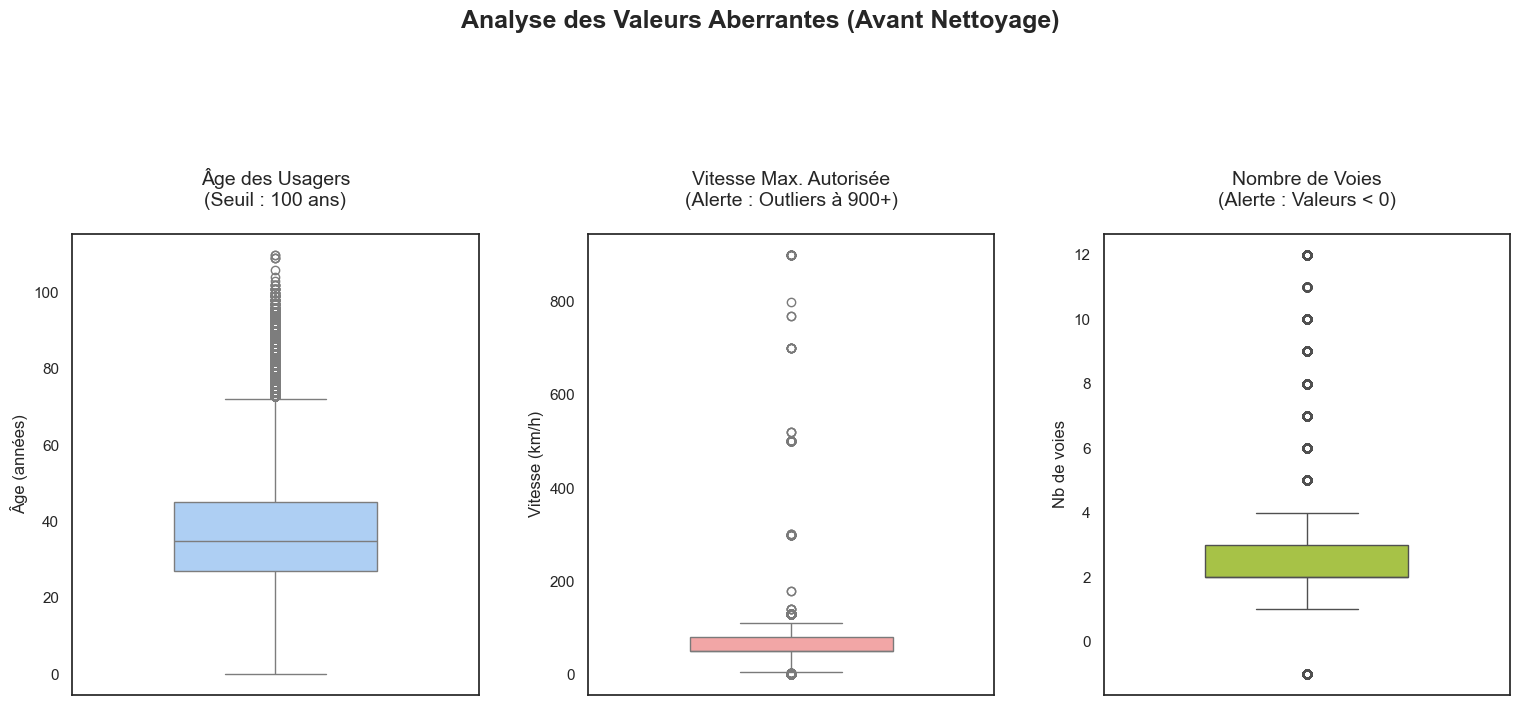

In [18]:
# On définit un style plus propre
sns.set_theme(style="white")
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Création de la figure avec une taille plus grande pour laisser respirer les titres
fig, axes = plt.subplots(1, 3, figsize=(16, 7))
fig.suptitle(
    "Analyse des Valeurs Aberrantes (Avant Nettoyage)",
    fontsize=18,
    fontweight="bold",
    y=1.05,
)

# 1. Boxplot Âge
sns.boxplot(y=df["age"], ax=axes[0], color="#A2CFFE", width=0.5)
axes[0].set_title("Âge des Usagers\n(Seuil : 100 ans)", pad=20)
axes[0].set_ylabel("Âge (années)")

# 2. Boxplot Vitesse (VMA)
sns.boxplot(y=df["vma"], ax=axes[1], color="#FF9999", width=0.5)
axes[1].set_title("Vitesse Max. Autorisée\n(Alerte : Outliers à 900+)", pad=20)
axes[1].set_ylabel("Vitesse (km/h)")

# 3. Boxplot Nombre de Voies
sns.boxplot(y=df["nbv"], ax=axes[2], color="#B2D732", width=0.5)
axes[2].set_title("Nombre de Voies\n(Alerte : Valeurs < 0)", pad=20)
axes[2].set_ylabel("Nb de voies")

# Ajustement automatique de l'espacement pour éviter les chevauchements
plt.tight_layout(pad=3.0)
plt.show()

In [19]:
# 1. Nettoyage de la Vitesse (VMA)
# On ramène tout ce qui est supérieur à 130 à la vitesse maximale autorisée en France
df.loc[df["vma"] > 130, "vma"] = 130

# 2. Nettoyage du Nombre de voies (NBV)
# On force en numérique et on remplace les valeurs < 1 par 2 (la norme standard)
df["nbv"] = pd.to_numeric(df["nbv"], errors="coerce")
df.loc[df["nbv"] < 1, "nbv"] = 2
df.loc[df["nbv"] > 10, "nbv"] = 2  # Plafonnement à 10 voies

# 3. Nettoyage de l'Âge
# On plafonne l'âge à 100 ans pour éviter les doyens extrêmes qui biaisent les statistiques
df.loc[df["age"] > 100, "age"] = 100

print("Valeurs aberrantes corrigées.")

Valeurs aberrantes corrigées.


# 3. Nettoyage de l'Âge
# On plafonne l'âge à 100 ans pour éviter les doyens extrêmes 
# qui biaisent les statistiques
df.loc[df["age"] > 100, "age"] = 100

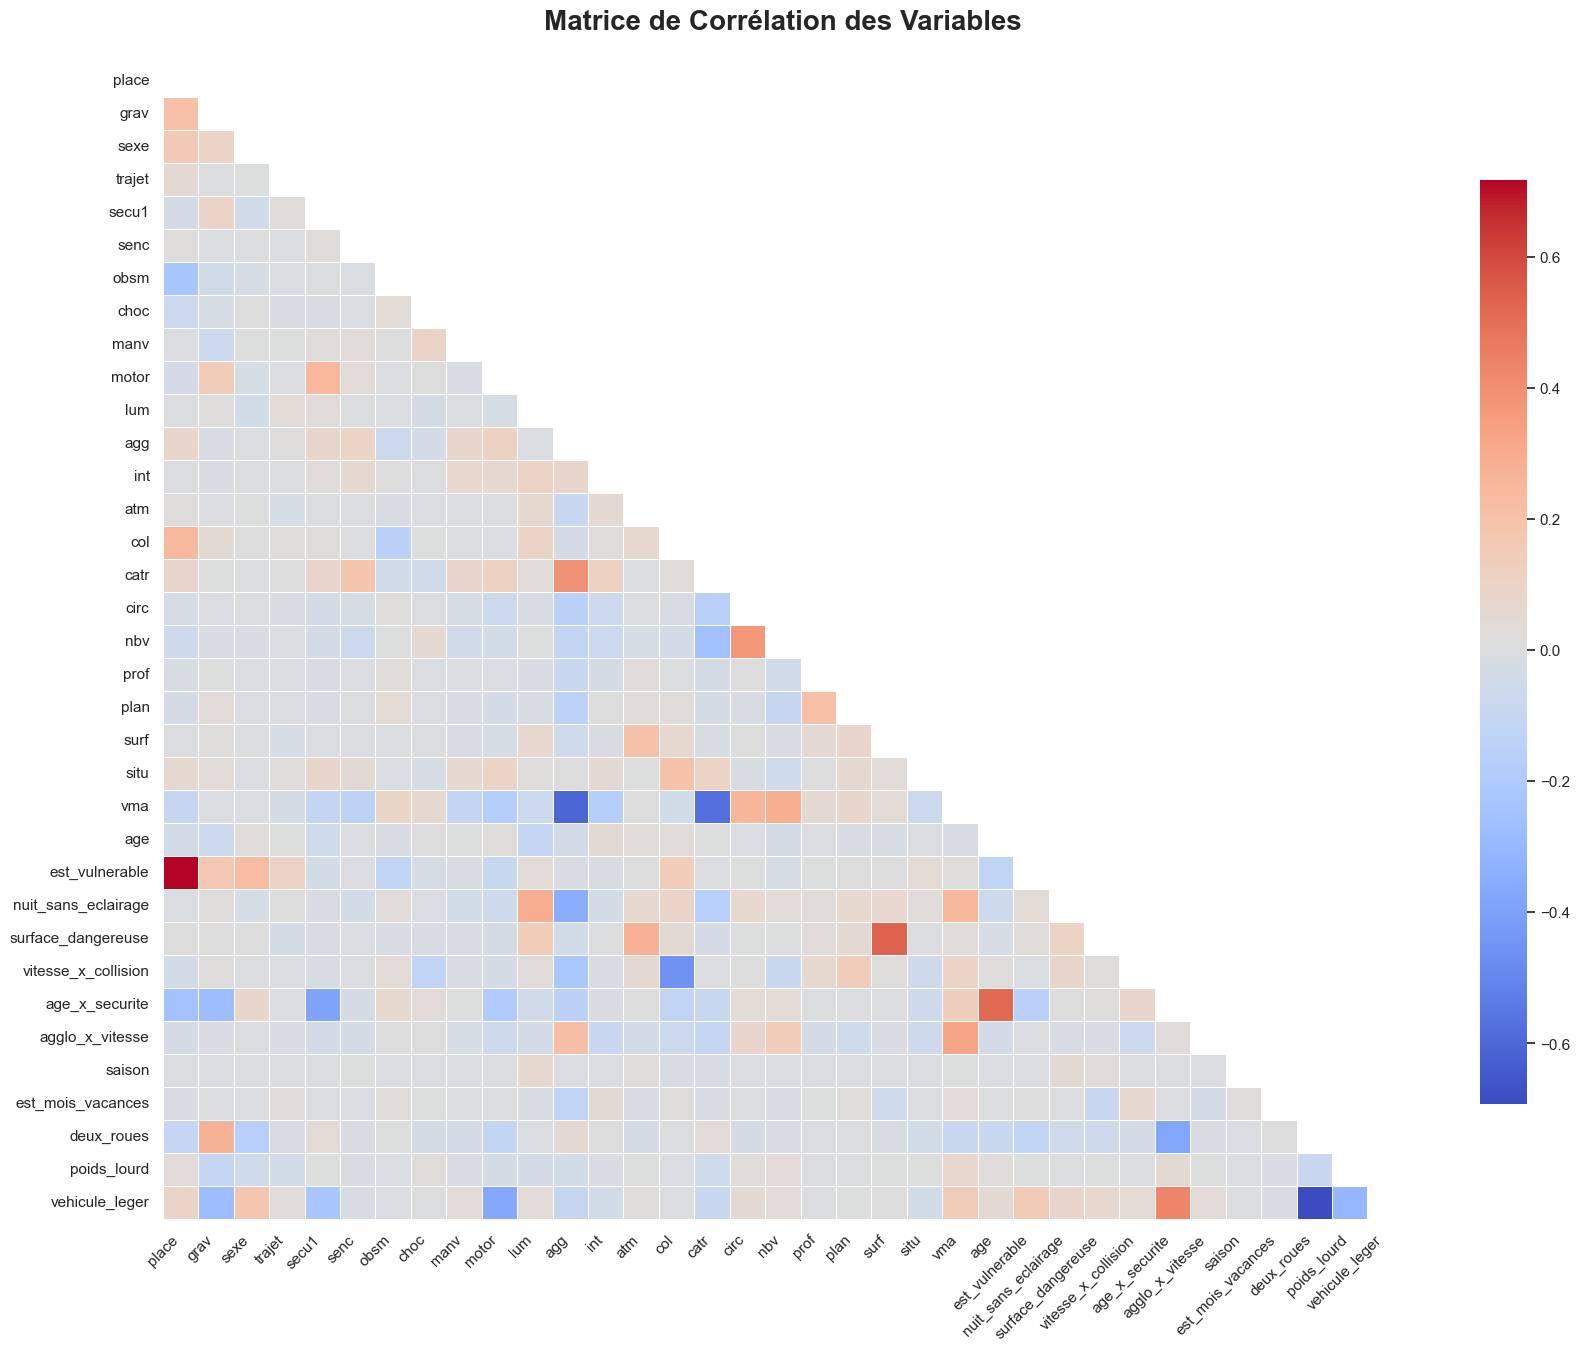

In [20]:
# Calcul de la matrice de corrélation
corr_matrix = df.corr()

# Création d'un masque pour cacher la partie supérieure (doublon)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Configuration de la figure
plt.figure(figsize=(20, 15))
plt.title(
    "Matrice de Corrélation des Variables", fontsize=20, fontweight="bold", pad=25
)

# Dessin de la heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,  # Mis à False car trop de colonnes pour lire les chiffres
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)

plt.xticks(rotation=45, ha="right")
plt.show()

In [21]:
# On retire les variables sources redondantes ou les binaires trop corrélées
df = df.drop(columns=["place"], errors="ignore")

In [22]:
# 1. On prend la valeur absolue de la matrice (pour capter corr positives et négatives)
corr_abs = corr_matrix.abs()

# 2. On "déroule" la matrice en une série
pairs = corr_abs.unstack()

# 3. On trie par ordre décroissant
sorted_pairs = pairs.sort_values(ascending=False)

# 4. On filtre : > 0.8 et < 1.0 (pour ignorer la corrélation d'une variable avec elle-même)
high_corr = sorted_pairs[(sorted_pairs > 0.8) & (sorted_pairs < 1.0)]

# 5. On retire les doublons (A-B est le même que B-A)
print("--- Paires de variables avec corrélation > 0.8")
if high_corr.empty:
    print("Aucune corrélation supérieure à 0.8 détectée. Votre dataset est propre !")
else:
    print(high_corr.drop_duplicates())

--- Paires de variables avec corrélation > 0.8
Aucune corrélation supérieure à 0.8 détectée. Votre dataset est propre !


In [23]:
# 4. On filtre : > 0.8 et < 1.0
# (pour ignorer la corrélation d'une variable avec elle-même)
high_corr = sorted_pairs[(sorted_pairs > 0.8) & (sorted_pairs < 1.0)]

In [24]:
# Export
output_file = "../data/processed/dataset_final.csv"
df.to_csv(output_file, index=False)
print(f"💾 Dataset sauvegardé : {output_file}")

💾 Dataset sauvegardé : ../data/processed/dataset_final.csv
